SUPRIYA K 24BAD118


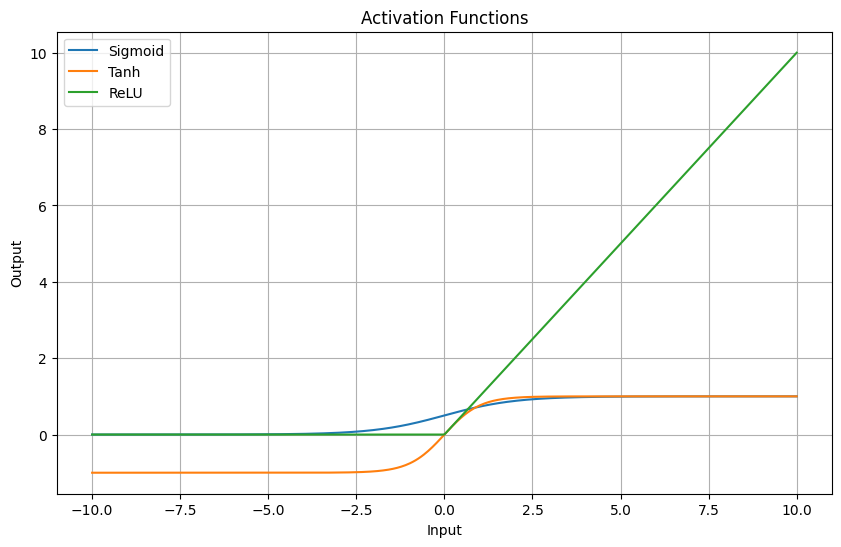

In [11]:
print("SUPRIYA K 24BAD118")
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10,10,500)

# Activation Functions
sigmoid = 1/(1+np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0,x)

plt.figure(figsize=(10,6))

plt.plot(x,sigmoid,label="Sigmoid")
plt.plot(x,tanh,label="Tanh")
plt.plot(x,relu,label="ReLU")

plt.title("Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(True)
plt.show()


SUPRIYA K 24BAD118


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Activation: sigmoid
Validation Accuracy: 0.9824561476707458
Validation Loss: 0.11917337775230408
Activation: tanh
Validation Accuracy: 0.9824561476707458
Validation Loss: 0.03636885806918144
Activation: relu
Validation Accuracy: 0.9824561476707458
Validation Loss: 0.048786524683237076


<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

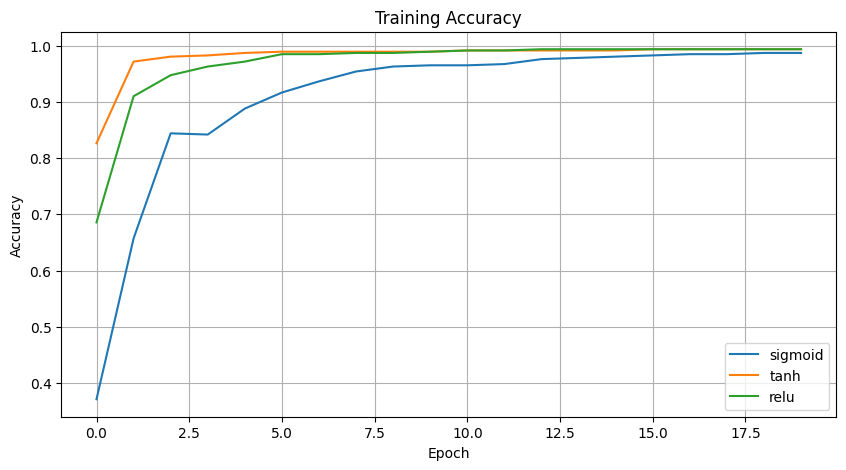

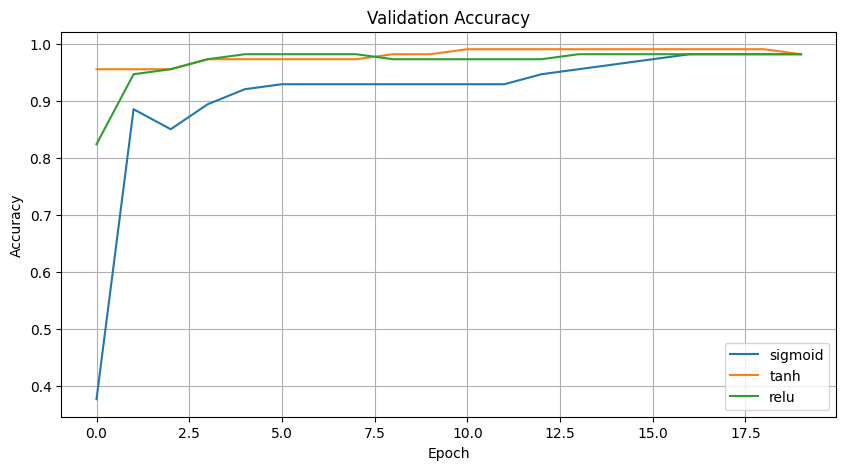

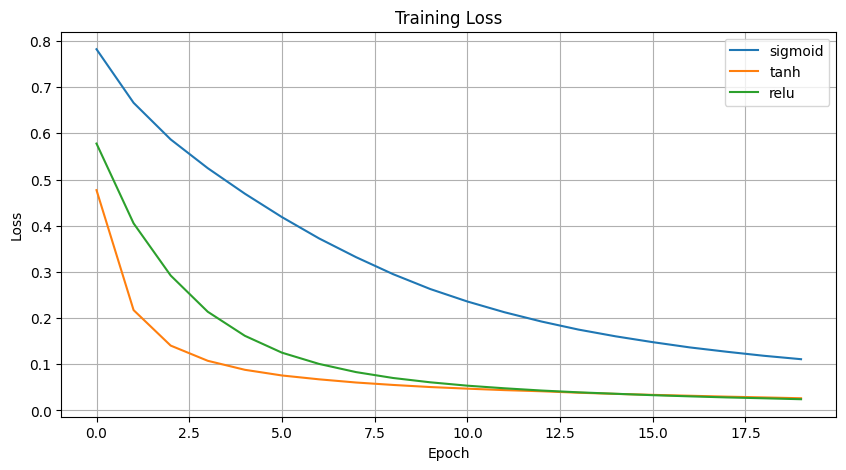

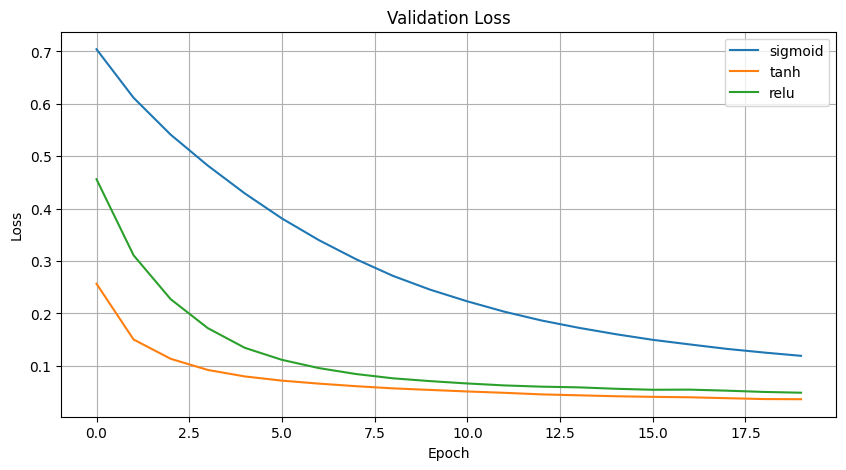

In [13]:
print("SUPRIYA K 24BAD118")
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load Dataset
data = pd.read_csv("/content/brca.csv")

X = data.drop("y",axis=1)
y = data["y"].map({"B":0,"M":1})

# Train Test Split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)

# Feature Scaling
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

activations=["sigmoid","tanh","relu"]

results={}

for act in activations:

    model=Sequential([
        Dense(32,activation=act,input_shape=(X_train.shape[1],)),
        Dense(16,activation=act),
        Dense(1,activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history=model.fit(
        X_train,
        y_train,
        validation_data=(X_test,y_test),
        epochs=20,
        batch_size=32,
        verbose=0
    )

    results[act]=history

    loss,acc=model.evaluate(X_test,y_test,verbose=0)
    print("Activation:",act)
    print("Validation Accuracy:",acc)
    print("Validation Loss:",loss)


    plt.figure(figsize=(10,5))

for act in activations:
    plt.plot(results[act].history['accuracy'],label=act)

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))

for act in activations:
    plt.plot(results[act].history['val_accuracy'],label=act)

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))

for act in activations:
    plt.plot(results[act].history['loss'],label=act)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))

for act in activations:
    plt.plot(results[act].history['val_loss'],label=act)

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()





SUPRIYA K 24BAD118
SGD
Validation Accuracy: 0.9473684430122375
Validation Loss: 0.13238318264484406
Momentum
Validation Accuracy: 0.9824561476707458
Validation Loss: 0.05589746683835983
RMSProp
Validation Accuracy: 0.9824561476707458
Validation Loss: 0.045201778411865234
Adam
Validation Accuracy: 0.9824561476707458
Validation Loss: 0.0554434210062027


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

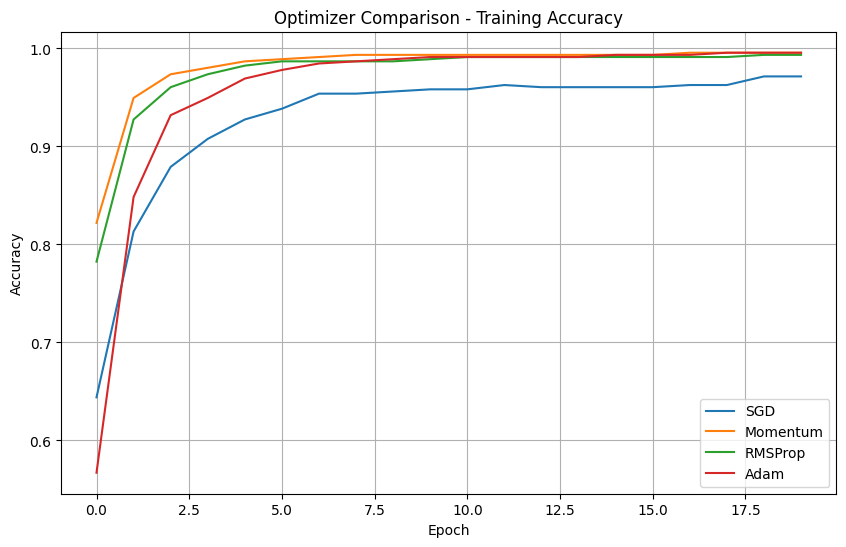

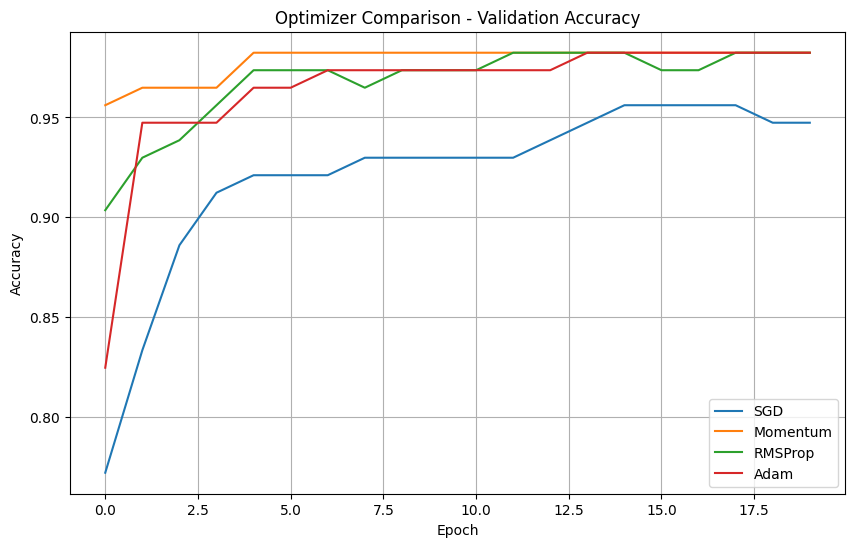

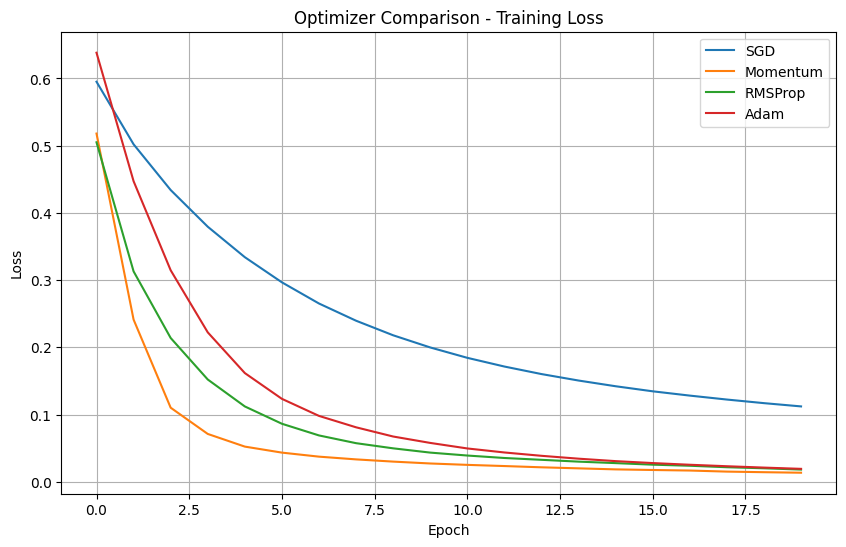

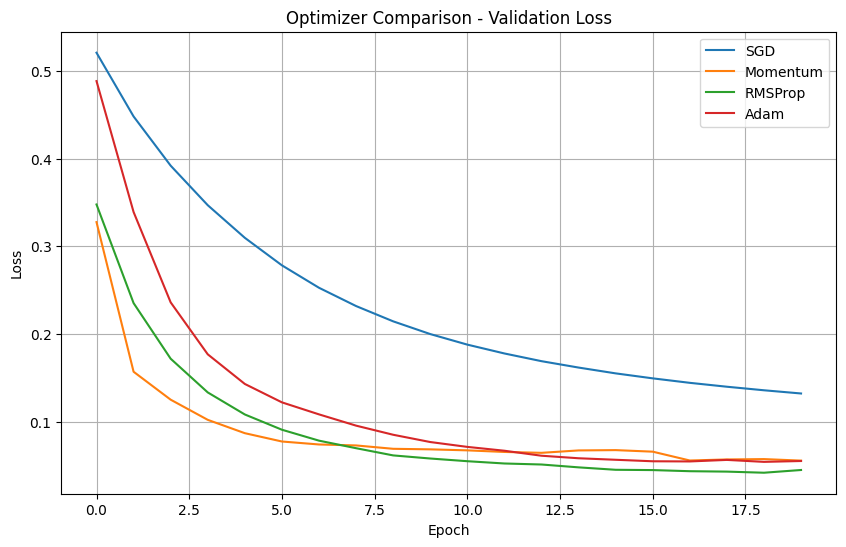

In [15]:
print("SUPRIYA K 24BAD118")
optimizers={
    "SGD":tf.keras.optimizers.SGD(),
    "Momentum":tf.keras.optimizers.SGD(momentum=0.9),
    "RMSProp":tf.keras.optimizers.RMSprop(),
    "Adam":tf.keras.optimizers.Adam()
}

history_dict={}

for name,opt in optimizers.items():

    model=Sequential([
        Dense(32,activation="relu",input_shape=(X_train.shape[1],)),
        Dense(16,activation="relu"),
        Dense(1,activation="sigmoid")
    ])

    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history=model.fit(
        X_train,
        y_train,
        validation_data=(X_test,y_test),
        epochs=20,
        batch_size=32,
        verbose=0
    )

    history_dict[name]=history

    loss,acc=model.evaluate(X_test,y_test,verbose=0)

    print(name)
    print("Validation Accuracy:",acc)
    print("Validation Loss:",loss)

    plt.figure(figsize=(10,6))

for name in history_dict:
    plt.plot(history_dict[name].history["accuracy"],label=name)

plt.title("Optimizer Comparison - Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))

for name in history_dict:
    plt.plot(history_dict[name].history["val_accuracy"],label=name)

plt.title("Optimizer Comparison - Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))

for name in history_dict:
    plt.plot(history_dict[name].history["loss"],label=name)

plt.title("Optimizer Comparison - Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))

for name in history_dict:
    plt.plot(history_dict[name].history["val_loss"],label=name)

plt.title("Optimizer Comparison - Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
print("SUPRIYA K _24BAD118")
from google.colab import drive

drive.mount('/content/drive')

model.save("/content/drive/MyDrive/ANN_Model.keras")

print("Model saved successfully.")

SUPRIYA K _24BAD118
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved successfully.
